# Fano factor vs engagement/disengagement bout structure (session level)

Companion to `ff_psth_ldabin.ipynb` (FF vs a session-level LDA-1 score) and `ff_psth_engagement.ipynb`
(FF within engaged vs disengaged trials). Neither answers this question: whether a session's
**rate of switching between the engaged and disengaged states, and how long it stays in each**,
predicts its neural variability. The predictor is a property of the *session's behavioural
dynamics*, not of the individual trial, so — like `lda_1` — it is tested with a session-level
permutation on a single-neuron GLM.

## The predictors are empirical, not fitted

Everything is counted off the per-trial GLM-HMM posterior already in
`4_mice/session_trial_meta_19-08-2026` (`p_state1`), which is bit-identical to
`GLM-HMM/merged_behavioral_and_states.pqt` — the original **per-mouse** fit (verified below, max
abs difference 0.0). State 1 is the engaged state: 87% of trials, 86% correct against 61% for
state 2.

| measure | definition | units |
|---|---|---|
| `switch_rate` | transitions / trials | per trial |
| `bout_eng` | engaged trials / (engaged -> disengaged transitions) | trials |
| `bout_dis` | disengaged trials / (disengaged -> engaged transitions) | trials |
| `frac_engaged` | state occupancy — **not** a transition measure, carried as a control | fraction |

Why not the per-session EM transition matrix in `GLM-HMM/lda_vs_session_params/`: those parameters
are re-fits of an HMM on one session, and `session_param_reliability.csv` shows they are the least
reliable quantities in the whole parameter set — `p_stay_engaged` has a split-half reliability of
0.030 (Spearman-Brown 0.059), implying that a *perfect* underlying relationship could show up as no
more than |r| = 0.24, and the FF-vs-`lda_1` effects are r_partial ~ 0.06. Counting bouts off the
per-mouse fit instead keeps the state definitions anchored in all of that mouse's data and spends
none of the session's trials on estimating parameters, which lifts the ceiling on an observable
correlation from 0.44 to 0.94 for the switch rate and from 0.24 to 0.68 for the engaged bout length.

The two routes agree only moderately -- r = +0.56 for the switch rate, +0.62 for the engaged bout
length, +0.52 for the disengagement probability. That disagreement is not a warning about the
empirical measures; it is the re-fit noise showing up directly, and it is why the fitted values are
carried through as a cross-check rather than used as the predictor.

**Bout length is the reciprocal of a transition probability, so only one of the pair is tested.**
`bout_eng = n_engaged / n(E->D)` is exactly `1 / p_disengage` (verified r = +1.0000), so a test on
`log bout_eng` and a test on `log p_disengage` are the same test with the sign flipped. Bout length
is the version reported, because trials are an interpretable unit. The bout estimator is the
occupancy-over-exits (hazard) form rather than a mean over observed runs, because a session's first
and last bouts are truncated by its boundaries: the hazard form is censoring-robust
(r = -0.03 with session length) while the mean-of-complete-runs form is not (r = +0.15).

Both bout lengths are log-transformed for the linear model — they are ratio-scaled and strongly
right-skewed (`bout_eng` median 60 trials, IQR 34-109). `switch_rate` stays on its natural scale.

## Read the reliability section before the result

Measurement noise in a predictor attenuates any correlation by `sqrt(reliability)`, so the ceiling
on what this analysis can observe is set by how repeatably each measure can be estimated within one
session. The cell below reports a split-half over **alternating blocks of `REL_BLOCK` trials**, with
transitions counted only *within* a block — concatenating alternate blocks and then differencing
would invent a switch at every seam, which for a sequence that switches ~3% of the time would swamp
the signal. Measured this way: `switch_rate` 0.88, `bout_dis` 0.77, `frac_engaged` 0.95, and
`bout_eng` only ~0.45 (stable across block sizes from 30 to 200 trials, so it is a real limitation,
not a block-size artefact — the median session affords only ~8 engaged-to-disengaged exits to
estimate it from). `bout_eng` is therefore the weakest predictor of the three and its ceiling is
printed next to its result.

## Three confounds this notebook controls

1. **Occupancy, not transitions.** A session that is 97% engaged mechanically has almost no
   transitions, and disengaged trials already carry higher FF (`ff_psth_engagement.ipynb`). So a raw
   FF-vs-`switch_rate` correlation may be nothing but "more transitions means more disengaged
   trials". Two independent controls: `frac_engaged` enters as a covariate, and the whole analysis is
   repeated on **engaged trials only** — where the question becomes the sharp one, *does a session
   that flips more often show noisier neurons even during the stretches when it is engaged?*
2. **Reaction time.** Disengaged trials differ behaviourally, so a session with more transitions has
   a different RT distribution, and RT moves FF within a session (FF_pre is +0.15 higher on that
   session's own slow-RT half). `RT_MATCH` is the same implementation as in `ff_psth_ldabin.ipynb`:
   every session contributes the same reaction-time distribution.
3. **Slow drift.** FF across trials is inflated by any monotonic drift in rate, and sessions differ
   in how much they drift. `DETREND` removes each neuron's least-squares linear trend across
   session-order trials before any variance is computed, exactly as `ff_psth_engagement.ipynb` does.

One caveat on the source file: `merged_behavioral_and_states.pqt` carries its own behavioural
columns, and its `rewarded` agrees with the trial meta's `feedback` on only 83% of trials (mean 0.65
against an actual 0.83 correct), so those columns are not used for anything here — only `p_state1`,
which matches exactly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, hashlib
from scipy.stats import pearsonr, spearmanr
from iblatlas.regions import BrainRegions
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white'

In [2]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
clustering_dir = prefix + 'clustering/data_files/'
glmhmm_dir = prefix + 'GLM-HMM/lda_vs_session_params/'

REGION_LEVEL = 'beryl'     # 'cosmos' | 'beryl'
DROP = ['root', 'void']
MIN_NEURONS = 15           # per region in a session
REMOVE_CONDITION = True    # subtract stimulus (side x contrast) means before variance (mean-matched FF)
DETREND = True             # per-neuron linear detrend across session-order trials before FF
SEED = 0

# --- single-neuron window Fano factor (identical definition to ff_psth_ldabin.ipynb) ---
PRE_WINDOW = (-0.2, 0.0)   # baseline window (s)
POST_WINDOW = (0.1, 0.3)   # post-stimulus window (s)
MIN_TRIALS = 40            # min trials per session-region to trust a window FF estimate
MIN_WINDOW_COUNT = 0.5     # min mean spike count within the window (FF unstable below this)
N_PERM = 2000              # session-stratified permutation iterations
MOUSE_PERM = 600           # within-mouse permutation iterations
CORRECT_ONLY = False       # if True, keep only correct trials

# --- engagement / bout structure ---
ENGAGED_P_MIN = 0.5        # p_state1 >= this counts as an engaged trial (0.5 = the hard call)
MIN_TRIALS_ENGAGED = 40    # min engaged trials for the engaged-only FF metrics
MIN_OPPORTUNITIES = 10     # min trials in a state before its bout length / exit prob is estimated
REL_BLOCK = 30             # trials per block for the split-half reliability of the bout measures

# --- RT matching (same implementation and defaults as ff_psth_ldabin.ipynb) ---
RT_MATCH = False           # every session contributes the SAME reaction-time distribution
RT_MATCH_BINS = 8
RT_MATCH_MAX = 1.0         # see ff_psth_ldabin.ipynb: beyond ~2 s, matching conditions on a mediator
RT_MATCH_MODE = 'flat'     # 'flat' | 'pooled' | 'random' ('random' = the same-N power control)
RT_MATCH_DROP_NONPOS = True
RT_MATCH_N = None

br = BrainRegions()

# --- behaviour, including the per-mouse GLM-HMM engagement posterior (`p_state1`) ---
trials_df = pd.read_parquet(prefix + '4_mice/session_trial_meta_19-08-2026')
correct_by_session = (trials_df[trials_df['feedback'] == 'correct']
                      .groupby('session')['trial_id'].apply(set).to_dict())

# Verify `p_state1` really is the original per-mouse GLM-HMM posterior, positionally aligned.
_merged = pd.read_parquet(prefix + 'GLM-HMM/merged_behavioral_and_states.pqt')
_merged['trial_id'] = _merged.groupby('eid').cumcount()
_j = _merged.merge(trials_df[['session', 'trial_id', 'p_state1']], left_on=['eid', 'trial_id'],
                   right_on=['session', 'trial_id'], how='inner', suffixes=('_src', '_meta'))
print(f"p_state1 provenance: {len(_j)} trials over {_j['session'].nunique()} sessions joined to "
      f"merged_behavioral_and_states.pqt; max |difference| = "
      f"{(_j['p_state1_src'] - _j['p_state1_meta']).abs().max():.1e}")
_eng = trials_df['p_state1'] > ENGAGED_P_MIN
print(f"state 1 = engaged: {_eng.mean()*100:.0f}% of trials, "
      f"{(trials_df.loc[_eng, 'feedback'] == 'correct').mean()*100:.0f}% correct against "
      f"{(trials_df.loc[~_eng, 'feedback'] == 'correct').mean()*100:.0f}% for state 2")

# --- per-session EM re-fits: cross-check only, never the predictor (see the header) ---
glm_params = pd.read_csv(glmhmm_dir + 'session_glmhmm_k2_params.csv').rename(columns={'unit_id': 'session'})
glm_rel = pd.read_csv(glmhmm_dir + 'session_param_reliability.csv')

# LDA-1 is not the predictor here, but it is carried so this notebook's session set and any shared
# structure can be compared directly against ff_psth_ldabin.ipynb.
lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut19-08-2026').rename(columns={0: 'lda_1'})
lda1_map = dict(zip(lda['session'], lda['lda_1']))
print(f"trial meta: {len(trials_df)} trials, {trials_df['session'].nunique()} sessions, "
      f"{trials_df['mouse_name'].nunique()} mice | per-session EM re-fits available for "
      f"{len(glm_params)} sessions")

p_state1 provenance: 161339 trials over 255 sessions joined to merged_behavioral_and_states.pqt; max |difference| = 0.0e+00
state 1 = engaged: 87% of trials, 86% correct against 61% for state 2
trial meta: 161339 trials, 255 sessions, 58 mice | per-session EM re-fits available for 255 sessions


## Per-session bout structure, and how reliably it can be measured

In [3]:
def bout_measures(z, min_opp=MIN_OPPORTUNITIES):
    """Empirical bout structure of one session's engaged/disengaged sequence.

    `z` is the boolean engaged sequence in trial order. Everything is a count off that sequence --
    no model is re-fitted, so none of the session's trials are spent estimating parameters.

    Bout length is the occupancy-over-exits (hazard) estimator, `trials in state / exits from
    state`, NOT a mean over observed runs. A session's first and last bouts are truncated by its
    boundaries, and for the engaged state -- median bout ~60 trials against ~580 trials per session
    -- that censoring is a large fraction of the evidence. The hazard form is unaffected
    (r = -0.03 with session length) while the mean-of-complete-runs form inherits it (r = +0.15);
    both are returned so the choice is visible.

    `bout_eng` is exactly `1 / p_disengage` and `bout_dis` exactly `1 / p_reengage`, so testing a
    bout length and testing the corresponding transition probability are the same test with the
    sign flipped. Both are stored, but only the bout lengths are tested.
    """
    n = len(z)
    a, b = z[:-1], z[1:]
    n_eng_opp, n_dis_opp = int(a.sum()), int((~a).sum())
    n_ed, n_de = int((a & ~b).sum()), int((~a & b).sum())
    o = dict(n_trials_beh=n, frac_engaged=float(z.mean()), n_transitions=n_ed + n_de,
             n_eng_opp=n_eng_opp, n_dis_opp=n_dis_opp, n_exit_eng=n_ed, n_exit_dis=n_de,
             switch_rate=float((a != b).mean()) if len(a) else np.nan)
    o['bout_eng'] = n_eng_opp / n_ed if n_ed > 0 else np.nan
    o['bout_dis'] = n_dis_opp / n_de if n_de > 0 else np.nan
    o['p_disengage'] = n_ed / n_eng_opp if n_eng_opp >= min_opp else np.nan
    o['p_reengage'] = n_de / n_dis_opp if n_dis_opp >= min_opp else np.nan
    # complete (uncensored) runs, for the censoring comparison only
    edges = np.flatnonzero(np.diff(z.astype(int))) + 1
    runs = np.split(np.arange(n), edges)
    inner = runs[1:-1] if len(runs) > 2 else []
    le = [len(r) for r in inner if z[r[0]]]
    ld = [len(r) for r in inner if not z[r[0]]]
    o['bout_eng_complete'] = float(np.mean(le)) if le else np.nan
    o['bout_dis_complete'] = float(np.mean(ld)) if ld else np.nan
    return o


def block_reliability(z, block=REL_BLOCK):
    """The same statistics recomputed on alternating `block`-trial segments of one session.

    Transitions are counted only WITHIN a contiguous segment: concatenating alternate blocks and
    then differencing would invent a switch at every seam, and for a sequence that switches ~3% of
    the time that artefact would swamp the signal. Returns two dicts (odd blocks, even blocks).
    """
    bid = np.arange(len(z)) // block
    out = []
    for parity in (0, 1):
        segs = [bout_measures(z[bid == b], min_opp=5)
                for b in np.unique(bid[bid % 2 == parity]) if (bid == b).sum() >= block * 0.8]
        out.append({k: np.nanmean([s[k] for s in segs]) for k in segs[0]} if segs else {})
    return out


MEASURES = ['switch_rate', 'bout_eng', 'bout_dis', 'frac_engaged']
_rows = []
for _s, _g in trials_df.groupby('session'):
    _g = _g.sort_values('trial_id')
    _z = (_g['p_state1'] > ENGAGED_P_MIN).to_numpy()
    _r = {'session': _s, 'mouse_name': _g['mouse_name'].iloc[0], **bout_measures(_z)}
    _hA, _hB = block_reliability(_z)
    for _k in MEASURES:
        _r[f'{_k}__A'] = _hA.get(_k, np.nan); _r[f'{_k}__B'] = _hB.get(_k, np.nan)
    _rows.append(_r)
sess_df = pd.DataFrame(_rows)
sess_df['log_bout_eng'] = np.log(sess_df['bout_eng'])
sess_df['log_bout_dis'] = np.log(sess_df['bout_dis'])
sess_df['lda_1'] = sess_df['session'].map(lda1_map)
print(f"{len(sess_df)} sessions, {sess_df['mouse_name'].nunique()} mice")
print(f"sessions with zero transitions (bout length undefined): "
      f"{int((sess_df['n_transitions'] == 0).sum())}")

print(f"\n{'measure':<20}{'median':>10}{'IQR':>24}{'NaN':>7}")
for _m in ['switch_rate', 'n_transitions', 'bout_eng', 'bout_dis', 'p_disengage', 'p_reengage',
           'frac_engaged', 'n_trials_beh']:
    _v = sess_df[_m]
    print(f"{_m:<20}{_v.median():>10.4f}{f'{_v.quantile(.25):.4f} - {_v.quantile(.75):.4f}':>24}"
          f"{_v.isna().mean():>7.2f}")

print("\nbout length is the reciprocal of the exit probability, so only one of each pair is tested:")
for _a, _b in [('bout_eng', 'p_disengage'), ('bout_dis', 'p_reengage')]:
    _d = sess_df[[_a, _b]].dropna()
    print(f"  r({_a}, 1/{_b}) = {pearsonr(_d[_a], 1 / _d[_b])[0]:+.4f}")

print("\ncensoring: the hazard estimator must not track session length, the run-mean one does")
for _m in ['bout_eng', 'bout_eng_complete', 'bout_dis', 'bout_dis_complete', 'switch_rate']:
    _d = sess_df[[_m, 'n_trials_beh']].dropna()
    print(f"  r({_m:<18}, n_trials) = {pearsonr(_d[_m], _d['n_trials_beh'])[0]:+.3f}   (n = {len(_d)})")

print("\ncross-check against the per-session EM re-fits (used for nothing else)")
_cc = sess_df.merge(glm_params[['session', 'n_transitions_per_trial', 'p_stay_engaged',
                                'p_stay_disengaged', 'mean_dwell_engaged']], on='session', how='inner')
for _a, _b, _f in [('switch_rate', 'n_transitions_per_trial', lambda d: d['n_transitions_per_trial']),
                   ('p_disengage', 'p_stay_engaged', lambda d: 1 - d['p_stay_engaged']),
                   ('p_reengage', 'p_stay_disengaged', lambda d: 1 - d['p_stay_disengaged']),
                   ('bout_eng', 'mean_dwell_engaged', lambda d: d['mean_dwell_engaged'])]:
    _d = _cc.dropna(subset=[_a, _b])
    print(f"  {_a:<12} vs re-fit {_b:<20} r = {pearsonr(_d[_a], _f(_d))[0]:+.3f}  "
          f"rho = {spearmanr(_d[_a], _f(_d))[0]:+.3f}   (n = {len(_d)})")

# ---------------------------------------------------------------------------------------------
# Reliability and the attenuation ceiling. A predictor with reliability R attenuates any true
# correlation by sqrt(R), so sqrt(R) is the largest |r| this analysis could observe even if the
# underlying relationship were perfect. Read every null below against its own ceiling.
# ---------------------------------------------------------------------------------------------
_refit_of = {'switch_rate': 'n_transitions_per_trial', 'bout_eng': 'p_stay_engaged',
             'bout_dis': 'p_stay_disengaged', 'frac_engaged': 'frac_engaged'}
_refit = glm_rel.set_index('target')['r_full_spearman_brown'].to_dict()
print(f"\nreliability of each predictor: alternating {REL_BLOCK}-trial blocks off the per-mouse fit")
print("(what this notebook uses) against the per-session EM re-fit (what it deliberately avoids)")
print(f"{'measure':<14}{'block r':>10}{'Spearman-Brown':>16}{'ceiling |r|':>13}{'re-fit S-B':>13}"
      f"{'re-fit ceiling':>16}")
reliability = {}
for _m in MEASURES:
    _d = sess_df[[f'{_m}__A', f'{_m}__B']].dropna()
    _r = pearsonr(_d[f'{_m}__A'], _d[f'{_m}__B'])[0] if len(_d) > 10 else np.nan
    _sb = 2 * _r / (1 + _r) if np.isfinite(_r) else np.nan
    _rf = _refit.get(_refit_of[_m], np.nan)
    reliability[_m] = dict(block_r=_r, sb=_sb, ceiling=np.sqrt(max(_sb, 0)), refit_sb=_rf)
    print(f"{_m:<14}{_r:>10.3f}{_sb:>16.3f}{reliability[_m]['ceiling']:>13.3f}{_rf:>13.3f}"
          f"{np.sqrt(max(_rf, 0)):>16.3f}")
print("\nbout_eng is the weakest of the three: the median session affords only "
      f"{int(sess_df['n_exit_eng'].median())} engaged-to-disengaged exits to estimate it from,")
print("and its reliability is flat across block sizes from 30 to 200 trials, so this is a real")
print("limit rather than a block-size artefact. Compare each ceiling with the FF-vs-lda_1 effect")
print("size in ff_psth_ldabin.ipynb (r_partial ~ 0.06) before reading a null as evidence of absence.")

255 sessions, 58 mice
sessions with zero transitions (bout length undefined): 4

measure                 median                     IQR    NaN
switch_rate             0.0275         0.0144 - 0.0485   0.00
n_transitions          17.0000        8.0000 - 28.0000   0.00
bout_eng               60.2000      34.2000 - 108.8438   0.02
bout_dis                5.5000        2.5778 - 15.0000   0.03
p_disengage             0.0161         0.0084 - 0.0284   0.00
p_reengage              0.1583         0.0606 - 0.3450   0.08
frac_engaged            0.9156         0.8167 - 0.9602   0.00
n_trials_beh          583.0000     489.5000 - 734.5000   0.00

bout length is the reciprocal of the exit probability, so only one of each pair is tested:
  r(bout_eng, 1/p_disengage) = +1.0000
  r(bout_dis, 1/p_reengage) = +1.0000

censoring: the hazard estimator must not track session length, the run-mean one does
  r(bout_eng          , n_trials) = -0.027   (n = 250)
  r(bout_eng_complete , n_trials) = +0.149   (n = 2

## Single-neuron Fano factor per session, on all trials and on engaged trials only

Same metric as `ff_psth_ldabin.ipynb`'s `window_ff`: per neuron, the variance of
side x contrast-mean-subtracted spike counts in a fixed window divided by the raw mean count, for
`PRE_WINDOW` and `POST_WINDOW`, with `ff_quench = ff_pre - ff_post`. One pass over the firing-rate
files produces two versions of each:

- **all trials** — whatever `CORRECT_ONLY` / `RT_MATCH` leave, the direct analogue of the LDA-1
  notebook;
- **engaged trials only** (`p_engaged >= ENGAGED_P_MIN`) — the sharp version of the question. On all
  trials, any FF-vs-switch-rate relationship can be produced entirely by occupancy: more transitions
  means more disengaged trials, and disengaged trials already carry higher FF
  (`ff_psth_engagement.ipynb`). Restricted to engaged trials that route is closed, and what is left
  is whether a session that *flips more often* has noisier neurons even during the stretches when it
  is engaged.

`trial_idx` in the posteriors file is verified below to be the meta `trial_id`, which is the
firing-rate `trial_id` at offset 0, so the engagement label can be indexed straight onto the
firing-rate trial axis.

`DETREND` removes each neuron's least-squares linear trend across session-order trials before any
variance is taken (the `ff_psth_engagement.ipynb` implementation, mean-preserving and NaN-aware).
Without it, a session with more slow drift reads as a session with higher FF, and drift is not
independent of how much the animal's behavioural state wanders.

In [4]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols]); T = len(tcols)
binwidth = float(np.median(np.diff(tsec)))
pre_mask = (tsec >= PRE_WINDOW[0]) & (tsec < PRE_WINDOW[1])
post_mask = (tsec >= POST_WINDOW[0]) & (tsec < POST_WINDOW[1])
print(f"{len(pkl_files)} firing-rate files | {T} bins, {tsec.min():.2f}..{tsec.max():.2f}s, "
      f"binwidth {binwidth*1000:.1f} ms | pre {pre_mask.sum()} bins, post {post_mask.sum()} bins")

# --- engagement label per (session, trial_id), straight off the per-mouse posterior ---
engaged_by_session = {s: g.set_index('trial_id')['p_state1'] for s, g in trials_df.groupby('session')}
# A session needs an estimable bout structure to be usable at all: zero transitions leaves both bout
# lengths undefined, so it carries no information about the predictor and is dropped here rather
# than silently contributing to the intercept.
usable_sessions = set(sess_df.loc[sess_df['n_transitions'] > 0, 'session'])
print(f"engagement posteriors for {len(engaged_by_session)} sessions; "
      f"{len(usable_sessions)} have an estimable bout structure")

# --- RT matching: identical implementation to ff_psth_ldabin.ipynb ---
_rt = trials_df.loc[trials_df['session'].isin(usable_sessions), ['session', 'trial_id', 'reaction']].copy()
_rt_pos = (_rt['reaction'] > 0) & (_rt['reaction'] < (RT_MATCH_MAX if RT_MATCH_MAX else np.inf))
rt_bin_edges = np.quantile(np.log(_rt.loc[_rt_pos, 'reaction']), np.linspace(0, 1, RT_MATCH_BINS + 1))
rt_bin_edges[0], rt_bin_edges[-1] = -np.inf, np.inf
_rt['rt_bin'] = -1
_rt.loc[_rt_pos, 'rt_bin'] = np.searchsorted(
    rt_bin_edges, np.log(_rt.loc[_rt_pos, 'reaction']), side='right') - 1
rt_bin_by_session = {s: g.set_index('trial_id')['rt_bin'] for s, g in _rt.groupby('session')}
_elig = _rt['rt_bin'] >= 0
rt_bin_weights = np.array([(_rt['rt_bin'] == k).sum() / _elig.sum() for k in range(RT_MATCH_BINS)])


def rt_match(trials, session, keep):
    """Down-select `keep` to an equal number of trials per global log-RT quantile bin, so every
    session's retained RT distribution is identical. Selection is by a hash of (session, trial_id)
    rather than an RNG draw, so a trial's fate does not depend on which other trials share its file.
    See ff_psth_ldabin.ipynb for the full rationale."""
    rb = rt_bin_by_session.get(session)
    if rb is None:
        return np.zeros(len(trials), dtype=bool)
    b = pd.to_numeric(rb.reindex(trials), errors='coerce').to_numpy()
    b = np.where(np.isfinite(b), b, -1).astype(int)
    if RT_MATCH_DROP_NONPOS:
        keep = keep & (b >= 0)
    per_bin = [np.where(keep & (b == k))[0] for k in range(RT_MATCH_BINS)]
    out = np.zeros(len(trials), dtype=bool)
    key = np.array([int(hashlib.md5(f"{session}|{t}|{SEED}".encode()).hexdigest()[:8], 16)
                    for t in trials])
    n_per = min(len(pos) for pos in per_bin)
    if RT_MATCH_N:
        n_per = min(n_per, RT_MATCH_N // RT_MATCH_BINS)
    if RT_MATCH_MODE == 'flat':
        take = [n_per] * RT_MATCH_BINS
    elif RT_MATCH_MODE == 'pooled':
        n_tot = min((len(pos) / w if w > 0 else np.inf) for pos, w in zip(per_bin, rt_bin_weights))
        if RT_MATCH_N:
            n_tot = min(n_tot, RT_MATCH_N)
        take = [int(np.floor(n_tot * w)) for w in rt_bin_weights]
    elif RT_MATCH_MODE == 'random':
        # Power control: same eligible pool and same trial count as 'flat', but each session keeps
        # its own RT distribution -- so 'flat' vs 'random' separates "the effect was RT" from "the
        # effect was the trials matching threw away". See ff_psth_ldabin.ipynb.
        elig = np.concatenate(per_bin) if per_bin else np.array([], dtype=int)
        n_take = min(n_per * RT_MATCH_BINS, len(elig))
        if n_take:
            out[elig[np.argsort(key[elig])[:n_take]]] = True
        return out
    else:
        raise ValueError(f"RT_MATCH_MODE must be 'flat', 'pooled' or 'random', got {RT_MATCH_MODE!r}")
    for pos, n in zip(per_bin, take):
        if n > 0:
            out[pos[np.argsort(key[pos])[:n]]] = True
    return out


def trial_mask(trials, session):
    """CORRECT_ONLY and RT_MATCH, composed. RT_MATCH is applied last, so it matches the RT
    distribution of whatever the other filters left behind."""
    m = np.ones(len(trials), dtype=bool)
    if CORRECT_ONLY:
        s = correct_by_session.get(session, set())
        m &= np.array([t in s for t in trials], dtype=bool)
    if RT_MATCH:
        m = rt_match(trials, session, m)
    return m


def detrend_trials(a, pos, axis):
    """Remove the least-squares linear trend of `a` along `axis` (session-order trial position
    `pos`), preserving each series' mean over its FINITE entries. NaN-aware: missing neuron x trial
    samples stay NaN and are excluded from the fit. Copied from ff_psth_engagement.ipynb so the two
    notebooks detrend identically."""
    x = pos.astype(float)
    shape = [1] * a.ndim; shape[axis] = len(x)
    xb = x.reshape(shape)
    m = np.isfinite(a)
    n = m.sum(axis=axis, keepdims=True)
    with np.errstate(invalid='ignore', divide='ignore'):
        xbar = np.nansum(np.where(m, xb, 0.0), axis=axis, keepdims=True) / n
        xc = xb - xbar
        denom = np.nansum(np.where(m, xc * xc, 0.0), axis=axis, keepdims=True)
        slope = np.nansum(np.where(m, a, 0.0) * np.where(m, xc, 0.0), axis=axis, keepdims=True) / denom
    slope = np.where(np.isfinite(slope), slope, 0.0)
    return a - slope * xc


def window_ff(counts, cond):
    """counts: neurons x trials, window-summed spike counts. Per-neuron condition-adjusted
    (mean-matched) Fano factor -- the same metric as ff_psth_ldabin.ipynb's window_ff."""
    mean = np.nanmean(counts, axis=1)
    if REMOVE_CONDITION:
        resid = counts.astype(float).copy()
        for cc in pd.unique(cond):
            ci = np.where(cond == cc)[0]
            resid[:, ci] -= np.nanmean(counts[:, ci], axis=1, keepdims=True)
        var = np.nanvar(resid, axis=1, ddof=1)
    else:
        var = np.nanvar(counts, axis=1, ddof=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        ff = var / (mean + 1e-6)
    ff[(mean <= MIN_WINDOW_COUNT) | ~np.isfinite(ff)] = np.nan
    return ff


neuron_records = []
n_sess_used = 0
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        if session not in usable_sessions: continue
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        neurons = sorted(d['nuid'].unique()); nidx = {n: k for k, n in enumerate(neurons)}
        trials = sorted(d['trial_id'].unique()); tix = {t: k for k, t in enumerate(trials)}
        # A holds per-bin spike COUNTS (the t_* columns are rates, so x binwidth), as in ff_psth_ldabin
        A = np.full((len(neurons), len(trials), T), np.nan)
        A[d['nuid'].map(nidx).values, d['trial_id'].map(tix).values, :] = d[tcols].values * binwidth

        na = d.groupby('nuid')['area'].first().reindex(neurons)
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(na.dropna().unique(), br.acronym2acronym(na.dropna().unique(), mapping='Cosmos')))
            na = na.map(cmap)
        neu_area = na.values
        conds = d.drop_duplicates('trial_id').set_index('trial_id')['condition'].reindex(trials).values

        keep = trial_mask(trials, session)
        kept_idx = np.where(keep)[0]
        if len(kept_idx) < MIN_TRIALS: continue
        cond_kept = conds[kept_idx]
        p_eng = engaged_by_session[session].reindex(np.array(trials)[kept_idx]).to_numpy()
        eng_local = np.where(np.isfinite(p_eng) & (p_eng >= ENGAGED_P_MIN))[0]

        counts_pre = np.nansum(A[:, kept_idx][:, :, pre_mask], axis=2)
        counts_post = np.nansum(A[:, kept_idx][:, :, post_mask], axis=2)
        if DETREND:
            # Detrend across the FULL kept-trial sequence, once, before any subsetting: a
            # label-independent linear transform, so the all-trial and engaged-only metrics are
            # detrended consistently rather than each against its own subsequence.
            pos = np.arange(len(kept_idx), dtype=float)
            counts_pre = detrend_trials(counts_pre, pos, axis=1)
            counts_post = detrend_trials(counts_post, pos, axis=1)

        for region in pd.unique(neu_area):
            if region is None or (isinstance(region, float) and np.isnan(region)): continue
            ni = np.where(neu_area == region)[0]
            if len(ni) < MIN_NEURONS: continue
            ff_pre = window_ff(counts_pre[ni], cond_kept)
            ff_post = window_ff(counts_post[ni], cond_kept)
            if len(eng_local) >= MIN_TRIALS_ENGAGED:
                ff_pre_e = window_ff(counts_pre[ni][:, eng_local], cond_kept[eng_local])
                ff_post_e = window_ff(counts_post[ni][:, eng_local], cond_kept[eng_local])
            else:
                ff_pre_e = ff_post_e = np.full(len(ni), np.nan)
            ok = np.isfinite(ff_pre) & np.isfinite(ff_post)
            for k, nu in enumerate(np.array(neurons)[ni]):
                if not ok[k]: continue
                neuron_records.append(dict(
                    session=session, region=region, nuid=nu,
                    n_trials=len(kept_idx), n_trials_eng=len(eng_local),
                    ff_pre=ff_pre[k], ff_post=ff_post[k], ff_quench=ff_pre[k] - ff_post[k],
                    ff_pre_eng=ff_pre_e[k], ff_post_eng=ff_post_e[k],
                    ff_quench_eng=ff_pre_e[k] - ff_post_e[k]))
        n_sess_used += 1
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")

neuron_df = pd.DataFrame(neuron_records)
neuron_df['log_ff_pre'] = np.log(neuron_df['ff_pre'].clip(lower=1e-6))
neuron_df['log_ff_post'] = np.log(neuron_df['ff_post'].clip(lower=1e-6))
neuron_df['log_ff_pre_eng'] = np.log(neuron_df['ff_pre_eng'].clip(lower=1e-6))
neuron_df['log_ff_post_eng'] = np.log(neuron_df['ff_post_eng'].clip(lower=1e-6))
neuron_df = neuron_df.merge(
    sess_df[['session', 'mouse_name', 'switch_rate', 'bout_eng', 'bout_dis', 'log_bout_eng',
             'log_bout_dis', 'p_disengage', 'p_reengage', 'frac_engaged', 'n_transitions',
             'lda_1']], on='session', how='left')
print(f"\nSingle-neuron FF table: {len(neuron_df)} neurons | {neuron_df['session'].nunique()} sessions "
      f"| {neuron_df['mouse_name'].nunique()} mice | {neuron_df['region'].nunique()} regions")
print(f"engaged-only metrics available for {neuron_df['ff_pre_eng'].notna().sum()} neurons "
      f"({neuron_df.loc[neuron_df['ff_pre_eng'].notna(), 'session'].nunique()} sessions "
      f"with >= {MIN_TRIALS_ENGAGED} engaged trials)")
print(f"trials per session: all median {neuron_df.groupby('session')['n_trials'].first().median():.0f}, "
      f"engaged median {neuron_df.groupby('session')['n_trials_eng'].first().median():.0f}")

400 firing-rate files | 90 bins, -0.50..1.00s, binwidth 17.0 ms | pre 12 bins, post 12 bins
engagement posteriors for 255 sessions; 251 have an estimable bout structure


  100/400 files...


  200/400 files...


  300/400 files...


  400/400 files...

Single-neuron FF table: 17391 neurons | 232 sessions | 58 mice | 172 regions
engaged-only metrics available for 17293 neurons (232 sessions with >= 40 engaged trials)
trials per session: all median 399, engaged median 372


## Test: single-neuron FF vs the session's transition probability

`metric ~ predictor + C(region) + n_trials` (+ `frac_engaged` in the controlled variant), fitted at
the **single-neuron** level with a **session-level** predictor — the same machinery as
`ff_psth_ldabin.ipynb`'s `age_effect_test`, so the numbers are directly comparable to the FF-vs-LDA-1
rows. `ff_pre` / `ff_post` are strictly positive and right-skewed so they are log-transformed;
`ff_quench` is a signed difference and stays on its natural scale.

**Two permutation nulls, and why the mouse-level one differs from the LDA-1 notebook's.** For
`lda_1`, which is constant within a mouse, that notebook relabels whole mice. A transition rate is
*not* constant within a mouse — it varies session to session — so relabelling whole mice would
destroy the within-mouse variation that carries most of the signal and test the wrong hypothesis.
The clustered null here permutes the predictor **among the sessions of the same mouse**, which asks:
within a mouse, do its higher-switching sessions have higher FF? The between-mouse share of the
predictor's variance is reported so it is clear how much each null has to work with.

**Attenuation.** `r_max = r_partial / ceiling` is what the observed partial correlation would
correspond to if the predictor were measured perfectly, using the pessimistic ceiling from the
reliability table. It is the number to compare against the FF-vs-`lda_1` effect size (r_partial
~ 0.06) when deciding whether a null here is informative.

`q_FDR` is Benjamini-Hochberg across the primary grid only (three metrics x three predictors, all
trials and engaged only), not across the control variants.

In [5]:
def _design_matrix(df, region_col='region', extra_covars=('n_trials',)):
    """Intercept + region dummies (drop first) + extra numeric covariates, as a plain array."""
    dummies = pd.get_dummies(df[region_col], drop_first=True)
    Z = pd.concat([pd.Series(1.0, index=df.index, name='Intercept'), dummies,
                   df[list(extra_covars)].astype(float)], axis=1)
    return Z.values.astype(float)


def effect_test(df, y_col, predictor, region_col='region', extra_covars=('n_trials',),
                n_perm=N_PERM, seed=SEED):
    """GLM slope as test statistic, session-stratified permutation p, and a partial-correlation JZS
    Bayes factor -- identical machinery to ff_psth_ldabin.ipynb's age_effect_test, with `predictor`
    a session-level engagement-transition measure instead of lda_1."""
    d = df.dropna(subset=[y_col, predictor, region_col] + list(extra_covars)).reset_index(drop=True)
    if len(d) < 100 or d[predictor].std() == 0:
        return None
    y = d[y_col].values.astype(float)
    x = d[predictor].values.astype(float)
    Z = _design_matrix(d, region_col, extra_covars)
    Zpinv = np.linalg.pinv(Z)

    # Frisch-Waugh-Lovell: residualize once, then the simple slope equals the full GLM coefficient
    y_resid = y - Z @ (Zpinv @ y)
    x_resid = x - Z @ (Zpinv @ x)
    slope_obs = np.sum(x_resid * y_resid) / np.sum(x_resid ** 2)
    r_partial, _ = pearsonr(x_resid, y_resid)
    n_eff = max(len(d) - (Z.shape[1] - 1), 3)
    bf10 = pg.bayesfactor_pearson(r_partial, n_eff)

    sess_to_x = d.groupby('session')[predictor].first()
    sess_index = d['session'].values
    rng = np.random.default_rng(seed)
    perm = np.empty(n_perm)
    for i in range(n_perm):
        sh = pd.Series(rng.permutation(sess_to_x.values), index=sess_to_x.index)
        xp = sh.reindex(sess_index).values.astype(float)
        xpr = xp - Z @ (Zpinv @ xp)
        perm[i] = np.sum(xpr * y_resid) / np.sum(xpr ** 2)
    p_perm = float((1 + np.sum(np.abs(perm) >= np.abs(slope_obs))) / (1 + n_perm))
    return dict(n=len(d), n_sessions=d['session'].nunique(), slope=slope_obs, r_partial=r_partial,
                bf10=bf10, p_perm=p_perm)


def within_mouse_perm_p(df, y_col, predictor, region_col='region', extra_covars=('n_trials',),
                        cluster='mouse_name', n_perm=MOUSE_PERM, seed=SEED):
    """Permutation p with the predictor shuffled among the sessions of the SAME mouse.

    A transition rate varies within a mouse, so relabelling whole mice (what ff_psth_ldabin.ipynb
    does for the constant-within-mouse lda_1) would destroy the variation being tested. This null
    keeps every mouse's set of session values and only reassigns which of its own sessions carried
    which value, so it isolates the within-mouse relationship. Mice contributing a single usable
    session cannot be permuted and drop out of the null by construction (their sessions keep their
    real value), which makes this null strictly conservative for them.
    """
    d = df.dropna(subset=[y_col, predictor, region_col, cluster] + list(extra_covars)).reset_index(drop=True)
    if len(d) < 100:
        return np.nan
    y = d[y_col].values.astype(float)
    Z = _design_matrix(d, region_col, extra_covars)
    Zpinv = np.linalg.pinv(Z)
    y_resid = y - Z @ (Zpinv @ y)

    def slope_of(x):
        xr = x - Z @ (Zpinv @ x)
        return np.sum(xr * y_resid) / np.sum(xr ** 2)

    obs = slope_of(d[predictor].values.astype(float))
    sess = d.groupby('session').agg(**{predictor: (predictor, 'first'), cluster: (cluster, 'first')})
    rng = np.random.default_rng(seed)
    null = np.empty(n_perm)
    for i in range(n_perm):
        shuffled = sess.groupby(cluster)[predictor].transform(
            lambda s: rng.permutation(s.values) if len(s) > 1 else s.values)
        null[i] = slope_of(d['session'].map(shuffled).values.astype(float))
    return float((1 + np.sum(np.abs(null) >= np.abs(obs))) / (1 + n_perm))


def bf_label(bf):
    if bf > 10: return 'strong H1'
    if bf > 3: return 'moderate H1'
    if bf < 1 / 10: return 'strong H0'
    if bf < 1 / 3: return 'moderate H0'
    return 'inconclusive'


def bh_fdr(p):
    """Benjamini-Hochberg step-up q-values."""
    p = np.asarray(p, dtype=float)
    ok = np.isfinite(p); q = np.full(len(p), np.nan)
    pv = p[ok]; n = len(pv)
    order = np.argsort(pv)
    qv = np.minimum.accumulate((pv[order] * n / np.arange(1, n + 1))[::-1])[::-1]
    out = np.empty(n); out[order] = np.minimum(qv, 1.0)
    q[ok] = out
    return q


def icc1(df, col, cluster='mouse_name'):
    """Between-cluster share of variance, ICC(1), for unbalanced cluster sizes.

    The obvious shortcut -- var(cluster means) / var(all values) -- is badly biased upward, because
    each cluster mean carries its own sampling noise: at ~4 sessions per mouse it returned 0.98 for
    session accuracy where the correct answer is 0.58. This uses the one-way random-effects
    decomposition with the unbalanced average cluster size, so the within-cluster mean square is
    subtracted off before the between-cluster variance is formed.
    """
    d = df.dropna(subset=[col, cluster])
    g = d.groupby(cluster)[col]
    k, m, n = g.size(), g.ngroups, len(d)
    if m < 2 or n <= m:
        return np.nan
    ms_between = (k * (g.mean() - d[col].mean()) ** 2).sum() / (m - 1)
    ms_within = ((d[col] - d[cluster].map(g.mean())) ** 2).sum() / (n - m)
    k0 = (n - (k ** 2).sum() / n) / (m - 1)
    var_between = max((ms_between - ms_within) / k0, 0.0)
    return var_between / (var_between + ms_within)


# --- how much of each predictor lives between mice rather than within (context for the two nulls) ---
print("between-mouse share of each predictor's variance, ICC(1). The remainder is within-mouse,")
print("which is what the within-mouse permutation has to work with -- a predictor that is almost")
print("entirely between-mouse gives that null very little, so a null there is not evidence against")
print("the pooled result:")
for _m in ['switch_rate', 'log_bout_eng', 'log_bout_dis', 'frac_engaged']:
    _d = sess_df.dropna(subset=[_m, 'mouse_name'])
    _gm = _d.groupby('mouse_name')[_m]
    print(f"  {_m:<14} ICC(1) = {icc1(sess_df, _m):.3f}  -> within-mouse share "
          f"{1 - icc1(sess_df, _m):.2f}   ({_gm.ngroups} mice, {(_gm.size() > 1).sum()} with >1 session)")

# switch_rate on its natural scale (a rate, bounded and only mildly skewed); the bout lengths in
# logs (ratio-scaled, bout_eng median 60 trials with an IQR of 34-109).
PREDICTORS = [('switch_rate', 'switch_rate'), ('log_bout_eng', 'bout_eng'),
              ('log_bout_dis', 'bout_dis')]
METRICS = [('log_ff_pre', 'FF_pre (log)'), ('log_ff_post', 'FF_post (log)'), ('ff_quench', 'FF_quench')]
VARIANTS = [('all trials', ''), ('engaged only', '_eng')]

rows = []
for vname, suffix in VARIANTS:
    for ycol, ylab in METRICS:
        y = ycol + suffix
        if y not in neuron_df.columns:
            continue
        for pred, rel_key in PREDICTORS:
            base = effect_test(neuron_df, y, pred)
            if base is None:
                continue
            ctrl = effect_test(neuron_df, y, pred, extra_covars=('n_trials', 'frac_engaged'))
            pm = within_mouse_perm_p(neuron_df, y, pred)
            rows.append(dict(variant=vname, metric=ylab, predictor=pred, **base, p_mouse=pm,
                             r_ctrl=(ctrl or {}).get('r_partial', np.nan),
                             p_ctrl=(ctrl or {}).get('p_perm', np.nan),
                             ceiling=reliability[rel_key]['ceiling']))
res = pd.DataFrame(rows)
res['r_max'] = res['r_partial'] / res['ceiling']
res['q_fdr'] = bh_fdr(res['p_perm'].values)

print(f"\n{'variant':<14}{'metric':<16}{'predictor':<14}{'n':>7}{'n_sess':>7}{'slope':>11}"
      f"{'r_part':>9}{'r_max':>8}{'BF10':>10}{'p_perm':>9}{'q_FDR':>8}{'p_mouse':>9}"
      f"{'r|frac_eng':>12}")
for _, r in res.iterrows():
    print(f"{r['variant']:<14}{r['metric']:<16}{r['predictor']:<14}{r['n']:>7}{r['n_sessions']:>7}"
          f"{r['slope']:>11.4f}{r['r_partial']:>9.4f}{r['r_max']:>8.3f}{r['bf10']:>10.3g}"
          f"{r['p_perm']:>9.4f}{r['q_fdr']:>8.3f}{r['p_mouse']:>9.4f}{r['r_ctrl']:>12.4f}")
print("\nslope units: log-FF (or FF) per unit predictor -- switch_rate spans ~0-0.15 while the log")
print("bout lengths span several natural-log units, so compare r_partial across rows, not slope.")
print("r_max = r_partial / ceiling, i.e. corrected for predictor measurement error using the")
print("pessimistic reliability. r|frac_eng adds frac_engaged as a covariate: if a transition effect")
print("collapses there, it was occupancy, not switching.")

share of each predictor's variance that is BETWEEN mice (the rest is within-mouse, which is
what the within-mouse permutation tests):
  switch_rate    between-mouse share ~ 0.66   (58 mice, 56 of them with >1 session)
  log_bout_eng   between-mouse share ~ 0.70   (58 mice, 56 of them with >1 session)
  log_bout_dis   between-mouse share ~ 0.93   (58 mice, 56 of them with >1 session)
  frac_engaged   between-mouse share ~ 0.62   (58 mice, 56 of them with >1 session)



variant       metric          predictor           n n_sess      slope   r_part   r_max      BF10   p_perm   q_FDR  p_mouse  r|frac_eng
all trials    FF_pre (log)    switch_rate     17391    232     0.9724   0.0250   0.026      2.05   0.2179   0.357   0.2995      0.0250
all trials    FF_pre (log)    log_bout_eng    17342    231    -0.0289  -0.0271  -0.040      5.16   0.1944   0.350   0.2063     -0.0297
all trials    FF_pre (log)    log_bout_dis    17123    228    -0.0011  -0.0015  -0.002   0.00982   0.9405   0.941   0.8852      0.0004
all trials    FF_post (log)   switch_rate     17391    232     1.8780   0.0515   0.054  7.78e+07   0.0175   0.063   0.1048      0.0507
all trials    FF_post (log)   log_bout_eng    17342    231    -0.0549  -0.0549  -0.081  1.76e+09   0.0130   0.058   0.0782     -0.0506
all trials    FF_post (log)   log_bout_dis    17123    228     0.0083   0.0120   0.014    0.0326   0.5967   0.671   0.2512     -0.0029
all trials    FF_quench       switch_rate     17391   

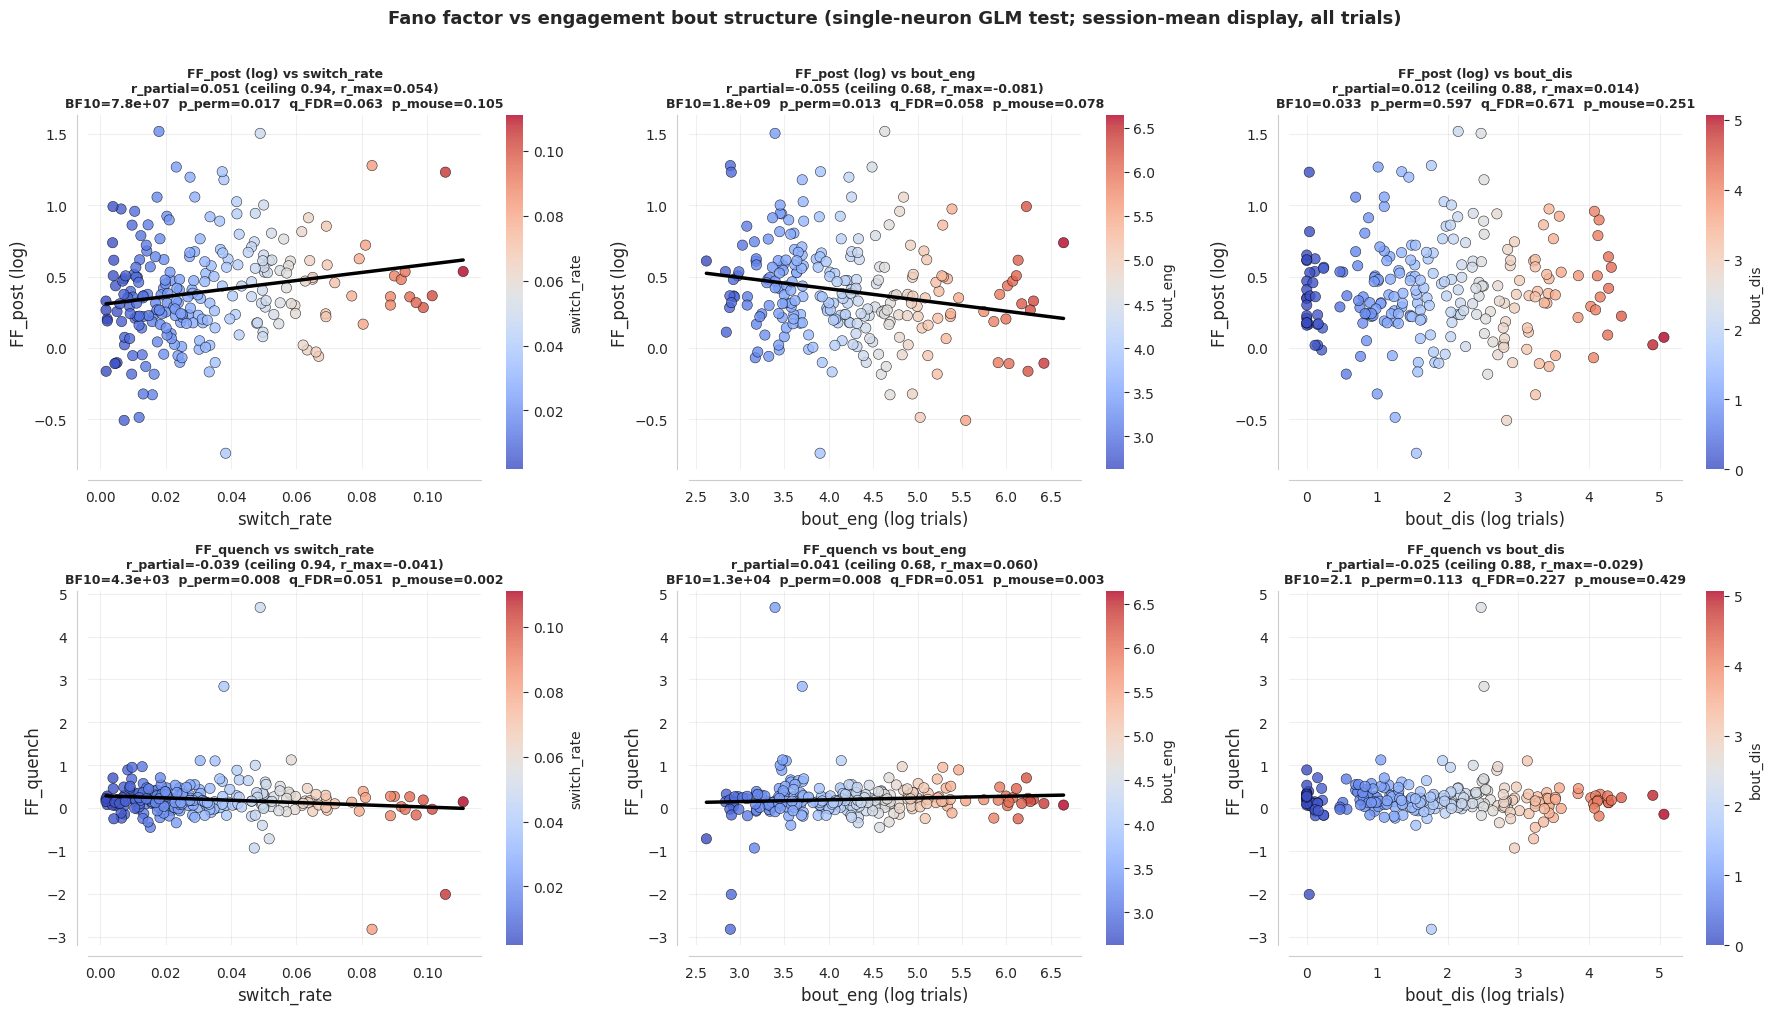

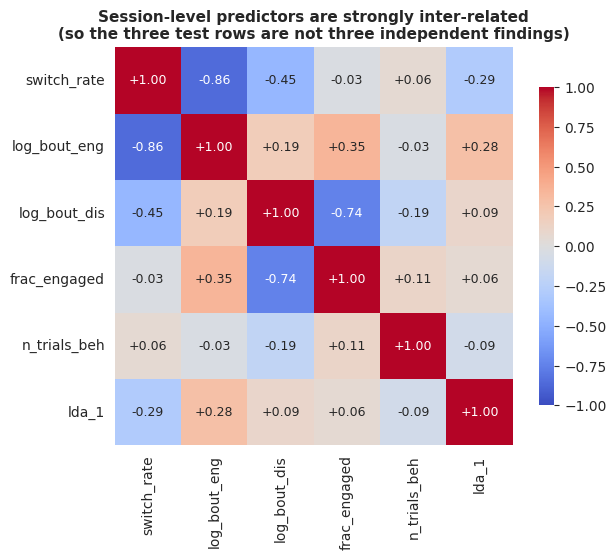

In [ ]:
# Session-mean FF against each bout measure. The GLM in the cell above is the test; this is display
# only, so the fit line is drawn from the single-neuron permutation result rather than from the
# session-level scatter (the two differ -- the scatter weights every session equally while the test
# weights by neurons and adjusts for region and trial count).
_panels = [(p, lab) for p, lab in PREDICTORS]
_metrics = [('log_ff_post', 'FF_post (log)'), ('ff_quench', 'FF_quench')]

fig, axes = plt.subplots(len(_metrics), len(_panels), figsize=(6 * len(_panels), 5 * len(_metrics)),
                         squeeze=False)
for _ri, (_ycol, _ylab) in enumerate(_metrics):
    for _ci, (_pred, _plab) in enumerate(_panels):
        ax = axes[_ri][_ci]
        _s = (neuron_df.dropna(subset=[_ycol, _pred])
              .groupby('session').agg(y=(_ycol, 'mean'), x=(_pred, 'first'),
                                      n=(_ycol, 'size')).reset_index())
        _res = res[(res['variant'] == 'all trials') & (res['metric'] == _ylab)
                   & (res['predictor'] == _pred)]
        sc = ax.scatter(_s['x'], _s['y'], c=_s['x'], cmap='coolwarm', alpha=0.8, s=55,
                        edgecolors='black', linewidth=0.4)
        if len(_res) and _res['p_perm'].iloc[0] < 0.05:
            _z = np.polyfit(_s['x'], _s['y'], 1)
            _xl = np.linspace(_s['x'].min(), _s['x'].max(), 100)
            ax.plot(_xl, np.polyval(_z, _xl), 'k-', lw=2.5)
        cb = fig.colorbar(sc, ax=ax); cb.set_label(_plab); cb.outline.set_visible(False)
        ax.set_xlabel(f"{_plab}" + (" (log trials)" if _pred.startswith('log_bout') else ""), fontsize=12)
        ax.set_ylabel(_ylab, fontsize=12)
        if len(_res):
            _r = _res.iloc[0]
            ax.set_title(f"{_ylab} vs {_plab}\nr_partial={_r['r_partial']:.3f} "
                         f"(ceiling {_r['ceiling']:.2f}, r_max={_r['r_max']:.3f})\n"
                         f"BF10={_r['bf10']:.2g}  p_perm={_r['p_perm']:.3f}  "
                         f"q_FDR={_r['q_fdr']:.3f}  p_mouse={_r['p_mouse']:.3f}",
                         fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.3); sns.despine(ax=ax, offset=8)
fig.suptitle('Fano factor vs engagement bout structure (single-neuron GLM test; session-mean display, '
             'all trials)', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# The predictors are not independent of each other, and none of them is independent of occupancy --
# worth seeing before reading three rows as three findings.
_cols = ['switch_rate', 'log_bout_eng', 'log_bout_dis', 'frac_engaged', 'n_trials_beh', 'lda_1']
_corr = sess_df[_cols].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(_corr, annot=True, fmt='+.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 9})
ax.set_title('Session-level predictors are strongly inter-related\n'
             '(so the three test rows are not three independent findings)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## How to read the table

**Ignore the Bayes factors; read the permutation p.** `BF10` is the JZS partial-correlation Bayes
factor at `n_eff` = *neurons*, and with ~17,000 neurons over ~230 sessions it treats every neuron in
a session as an independent observation of that session's behavioural state. It therefore returns
values like 1e+09 for r_partial = 0.05, which is pseudoreplication, not evidence. The column is kept
only because `ff_psth_ldabin.ipynb` reports it and the two tables should be comparable. `p_perm`,
`q_FDR` and `p_mouse` permute at the session and mouse level and are the statistics to trust.

**A null needs its ceiling.** Every row carries the `ceiling` its predictor's reliability imposes and
the `r_max = r_partial / ceiling` that follows. `bout_eng` has the lowest ceiling of the three
because the median session offers only a handful of engaged-to-disengaged exits to estimate it from,
so a null there is much weaker evidence than the same null on `switch_rate` or `frac_engaged`.

**`all trials` and `engaged only` answer different questions.** On all trials, any relationship can
be produced by occupancy alone — more transitions means more disengaged trials, and disengaged trials
already carry higher FF. A result that appears on all trials and disappears on engaged-only trials,
or that collapses when `frac_engaged` enters as a covariate (the `r|frac_eng` column), is occupancy.
A result that survives both is the interesting one: the *dynamics* of the behavioural state, not how
much time was spent in each state, tracking neural variability.

**The two permutation nulls bracket the level of inference.** `p_perm` shuffles the predictor across
all sessions and so pools between-mouse and within-mouse variation; `p_mouse` shuffles only among
the sessions of the same mouse and so asks whether a mouse's own higher-switching sessions have
higher FF. When the predictor is mostly a between-mouse quantity (see the variance-share printout)
the within-mouse null has little left to work with, and a null there is not evidence against the
pooled result.

**Cross-check the sign against `ff_psth_engagement.ipynb`.** That notebook establishes the
*trial-level* fact — disengaged trials have higher FF than engaged trials in the same session. If a
session-level relationship here has the opposite sign, it is not a refinement of that result but a
contradiction, and the likely culprit is the occupancy coupling rather than a genuine reversal.

**Things this notebook does not do.** It treats each session as one observation of a behavioural
regime and looks for a static association. It does not ask whether FF changes *around* a transition
(a peri-transition PSTH aligned to state changes, which would need the trial-resolved state sequence
rather than a session summary), nor whether the neural state leads or lags the behavioural one.
Those are the natural next questions if anything here survives.